In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import platform

# OS에 맞춰 한글 폰트 자동 설정
if platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# 마이너스기호 깨짐 방지
plt.rc('axes', unicode_minus=False)
# Seaborn 기본 스타일설정
sns.set_theme(style="whitegrid", font="AppleGothic" if platform.system() == 'Darwin' else "Malgun Gothic")

In [2]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

c:\ML_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 원본 데이터를 활용하여 가장 적합한 Regression 모델 선정
df = pd.read_csv("Oworld.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

target = "visitors"

# Weekend는 mon~sun과 겹치므로 제외
feature_cols = [c for c in df.columns if c not in ["date", "weekend", target]]

X = df[feature_cols]
y = df[target]

# train/test 데이터 분리 : TimeSeriesSplit() 사용
# 해당 데이터는 날짜로 인해 과거의 값이 현재의 값의 영향을 줄 수 있음
# 따라서 Random으로 나눈 것이 아닌 시계열 데이터처럼 나누는 함수 사용
tscv = TimeSeriesSplit(n_splits=5)
train_idx, test_idx = list(tscv.split(X))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Linear Regression용 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regression model 후보, Parameter는 교재에서 명시한 적당한 값
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0, random_state=42, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, random_state=42, n_jobs=-1
    ),
    "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=50),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, max_depth=-1, learning_rate=0.01,
        random_state=42, verbosity=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, depth=10, learning_rate=0.01,
        random_state=42, verbose=0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

results = []
predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    predictions[name] = y_pred


results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df)

                Model         RMSE          MAE        R2
0            CatBoost  1043.882929   705.258080  0.746851
1             XGBoost  1058.229595   723.221741  0.739845
2   Gradient Boosting  1073.010336   739.342889  0.732527
3       Random Forest  1075.988164   709.258756  0.731040
4            LightGBM  1120.448613   727.378157  0.708354
5       Decision Tree  1156.344219   744.000513  0.689368
6    Ridge Regression  1477.955406  1113.121606  0.492548
7    Lasso Regression  1479.166784  1113.027191  0.491716
8   Linear Regression  1479.588498  1113.252301  0.491426
9          ElasticNet  1836.677994  1469.968314  0.216321
10                SVR  2159.602078  1312.461492 -0.083476


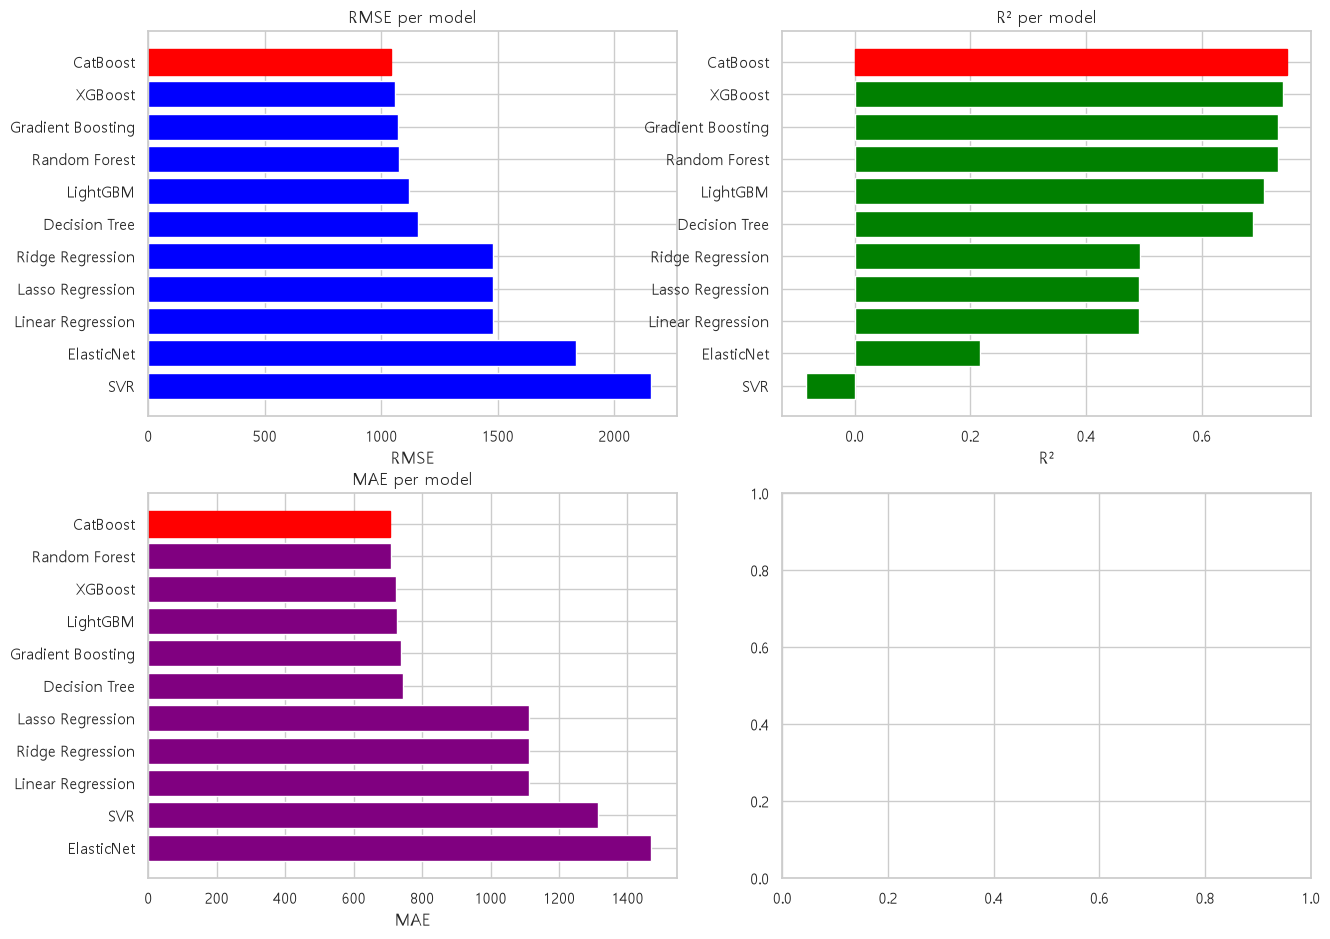

In [4]:
# 결과 시각화
results_df = results_df.sort_values("RMSE")
 
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
 
# (1) RMSE 비교
ax = axes[0, 0]
bars = ax.barh(results_df["Model"], results_df["RMSE"], color="blue")
bars[0].set_color("red")
ax.set_xlabel("RMSE")
ax.set_title("RMSE per model")
ax.invert_yaxis()
 
# (2) R2 비교
ax = axes[0, 1]
results_sorted_r2 = results_df.sort_values("R2", ascending=False)
bars = ax.barh(results_sorted_r2["Model"], results_sorted_r2["R2"], color="green")
bars[0].set_color("red")
ax.set_xlabel("R²")
ax.set_title("R² per model")
ax.invert_yaxis()
 
# (3) MAE 비교
ax = axes[1, 0]
results_sorted_mae = results_df.sort_values("MAE")
bars = ax.barh(results_sorted_mae["Model"], results_sorted_mae["MAE"], color="purple")
bars[0].set_color("red")
ax.set_xlabel("MAE")
ax.set_title("MAE per model")
ax.invert_yaxis()

-> 결론 : CatBoost Model이 가장 적합

In [34]:
# 선택한 모델과 가장 적합한 전처리 데이터 선정
# test1.csv : 날짜를 휴일, 휴일 전날, 월(One-hot Encoding)로 전처리
# test1_cat.csv : 날짜를 휴일, 휴일 전날, 월(Categorical)로 전처리
# test2.csv : 날짜를 휴일, 요일(One-hot Encoding), 월(One-hot Encoding)로 전처리
# test2_cate.csv : 날짜를 휴일, 요일(Categorical), 월(Categorical)로 전처리
# test3.csv : 날짜를 휴일, 월(One-hot Encoding)로 전처리
# test3_cate.csv : 날짜를 휴일, 월(Categorical)로 전처리
# test4.csv : 날짜를 주말, 휴일, 월(One-hot Encoding)로 전처리
# test4_cate.csv : 날짜를 주말, 휴일, 월(Categorical)로 전처리
files = ["test1.csv", "test1_cat.csv", "test2.csv", "test2_cat.csv",
         "test3.csv", "test3_cat.csv", "test4.csv", "test4_cat.csv"]

for file in files:
    df = pd.read_csv(file)

    target = "visitors"

    feature_cols = [c for c in df.columns if c not in [target]]

    X = df[feature_cols]
    y = df[target]

    tscv = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(tscv.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # 최적의 모델인 CatBoost 사용
    model = CatBoostRegressor(
            iterations=500, depth=10, learning_rate=0.01,
            random_state=42, verbose=0
        )
   
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_test = y_test

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(file)
    print(f"  MAE : {mae:,.1f} visitors")
    print(f"  RMSE: {rmse:,.1f} visitors")
    print(f"  R2  : {r2:.3f}")

test1.csv
  MAE : 583.3 visitors
  RMSE: 862.2 visitors
  R2  : 0.827
test1_cat.csv
  MAE : 609.0 visitors
  RMSE: 888.0 visitors
  R2  : 0.817
test2.csv
  MAE : 594.2 visitors
  RMSE: 899.8 visitors
  R2  : 0.812
test2_cat.csv
  MAE : 628.1 visitors
  RMSE: 969.4 visitors
  R2  : 0.782
test3.csv
  MAE : 630.1 visitors
  RMSE: 952.9 visitors
  R2  : 0.789
test3_cat.csv
  MAE : 664.6 visitors
  RMSE: 994.6 visitors
  R2  : 0.770
test4.csv
  MAE : 636.6 visitors
  RMSE: 994.3 visitors
  R2  : 0.770
test4_cat.csv
  MAE : 679.0 visitors
  RMSE: 1,051.5 visitors
  R2  : 0.743


-> 결론 : 날짜를 휴일, 휴일 전날, 월(One-hot Encoding)로 전처리

In [35]:
#Parameter Tuning(최적화)
df = pd.read_csv("test1.csv")

target = "visitors"

feature_cols = [c for c in df.columns if c not in [target]]

X = df[feature_cols]
y = df[target]

# CatBoost의 파라미터들에 대하여 학습
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_state": 42,
        "verbose": 0,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = CatBoostRegressor(**params, early_stopping_rounds=50)
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        pred = m.predict(X_val)
        actual = y_val
        scores.append(mean_absolute_error(actual, pred))
    return np.mean(scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(study.best_params, study.best_value)

[I 2026-08-13 15:34:35,245] A new study created in memory with name: no-name-ea7dfe9d-8833-4687-8e13-dd90dc09725c


Best trial: 0. Best value: 761.568:   2%|▏         | 1/50 [00:04<04:04,  5.00s/it]

[I 2026-08-13 15:34:40,256] Trial 0 finished with value: 761.5679316342324 and parameters: {'iterations': 1202, 'depth': 8, 'learning_rate': 0.04362145106406653, 'l2_leaf_reg': 9.709608390882826, 'bagging_temperature': 1.4616500383805797, 'random_strength': 3.304934181002372, 'border_count': 182}. Best is trial 0 with value: 761.5679316342324.


Best trial: 0. Best value: 761.568:   4%|▍         | 2/50 [00:06<02:31,  3.15s/it]

[I 2026-08-13 15:34:42,117] Trial 1 finished with value: 785.9161871633066 and parameters: {'iterations': 671, 'depth': 5, 'learning_rate': 0.011943284462409985, 'l2_leaf_reg': 5.8703748097299755, 'bagging_temperature': 0.05449841174911152, 'random_strength': 4.026770746959624, 'border_count': 66}. Best is trial 0 with value: 761.5679316342324.


...

[I 2026-08-13 15:38:39,728] Trial 47 finished with value: 739.7564417366955 and parameters: {'iterations': 1174, 'depth': 6, 'learning_rate': 0.01011433896607221, 'l2_leaf_reg': 6.46854923173942, 'bagging_temperature': 2.941135766926432, 'random_strength': 2.744832165242779, 'border_count': 75}. Best is trial 31 with value: 730.4499446842857.


Best trial: 31. Best value: 730.45:  98%|█████████▊| 49/50 [04:15<00:05,  5.92s/it]

[I 2026-08-13 15:38:50,881] Trial 48 finished with value: 755.4295746201176 and parameters: {'iterations': 1516, 'depth': 9, 'learning_rate': 0.034108575634179114, 'l2_leaf_reg': 11.070607450365664, 'bagging_temperature': 3.72214125450003, 'random_strength': 4.026612293133578, 'border_count': 210}. Best is trial 31 with value: 730.4499446842857.


Best trial: 31. Best value: 730.45: 100%|██████████| 50/50 [04:17<00:00,  5.16s/it]

[I 2026-08-13 15:38:53,014] Trial 49 finished with value: 754.1709991621614 and parameters: {'iterations': 962, 'depth': 5, 'learning_rate': 0.019778972659707638, 'l2_leaf_reg': 5.165252287432789, 'bagging_temperature': 1.2987538755743495, 'random_strength': 0.8462544967764696, 'border_count': 131}. Best is trial 31 with value: 730.4499446842857.
{'iterations': 1191, 'depth': 6, 'learning_rate': 0.02036869035136907, 'l2_leaf_reg': 11.60019634192424, 'bagging_temperature': 3.124914662904724, 'random_strength': 3.489476140373485, 'border_count': 85} 730.4499446842857


In [ ]:
df = pd.read_csv("feature.csv")

target = "visitors"

feature_cols = [c for c in df.columns if c not in [target]]

X = df[feature_cols]
y = df[target]

tscv = TimeSeriesSplit(n_splits=5)
train_idx, test_idx = list(tscv.split(X))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#위에서 학습한 parameter를 받아서 사용
model = CatBoostRegressor(
    **study.best_params, random_state=42, early_stopping_rounds=50)

# model = CatBoostRegressor(
#     iterations= 1191, depth= 8, learning_rate= 0.02036869035136907, l2_leaf_reg= 11.60019634192424, 
#     bagging_temperature = 3.124914662904724, random_strength = 3.489476140373485,
#     border_count= 85, random_state=42, early_stopping_rounds=50)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"  MAE : {mae:,.1f} visitors")
print(f"  RMSE: {rmse:,.1f} visitors")
print(f"  R2  : {r2:.3f}")

model.save_model("visitor_estimation_model.cbm")

0:	learn: 2554.4152013	total: 2.03ms	remaining: 2.41s
1:	learn: 2532.1351083	total: 3.54ms	remaining: 2.1s
2:	learn: 2505.5147475	total: 4.9ms	remaining: 1.94s
3:	learn: 2476.5252096	total: 5.84ms	remaining: 1.73s
4:	learn: 2450.3903402	total: 6.84ms	remaining: 1.62s
5:	learn: 2424.2577970	total: 7.82ms	remaining: 1.54s
6:	learn: 2402.7068639	total: 9.16ms	remaining: 1.55s
7:	learn: 2379.1946127	total: 10.5ms	remaining: 1.55s
8:	learn: 2359.1929494	total: 11.8ms	remaining: 1.55s
9:	learn: 2335.9596345	total: 12.9ms	remaining: 1.52s
10:	learn: 2313.1027529	total: 14ms	remaining: 1.51s
11:	learn: 2295.8964188	total: 14.6ms	remaining: 1.44s
12:	learn: 2280.8325918	total: 15.6ms	remaining: 1.41s
13:	learn: 2265.9557649	total: 16.1ms	remaining: 1.35s
14:	learn: 2248.5472473	total: 17.1ms	remaining: 1.34s
15:	learn: 2231.3424044	total: 18.2ms	remaining: 1.33s
16:	learn: 2209.1080233	total: 19.4ms	remaining: 1.34s
17:	learn: 2189.4091742	total: 20.4ms	remaining: 1.33s
18:	learn: 2173.7515808	

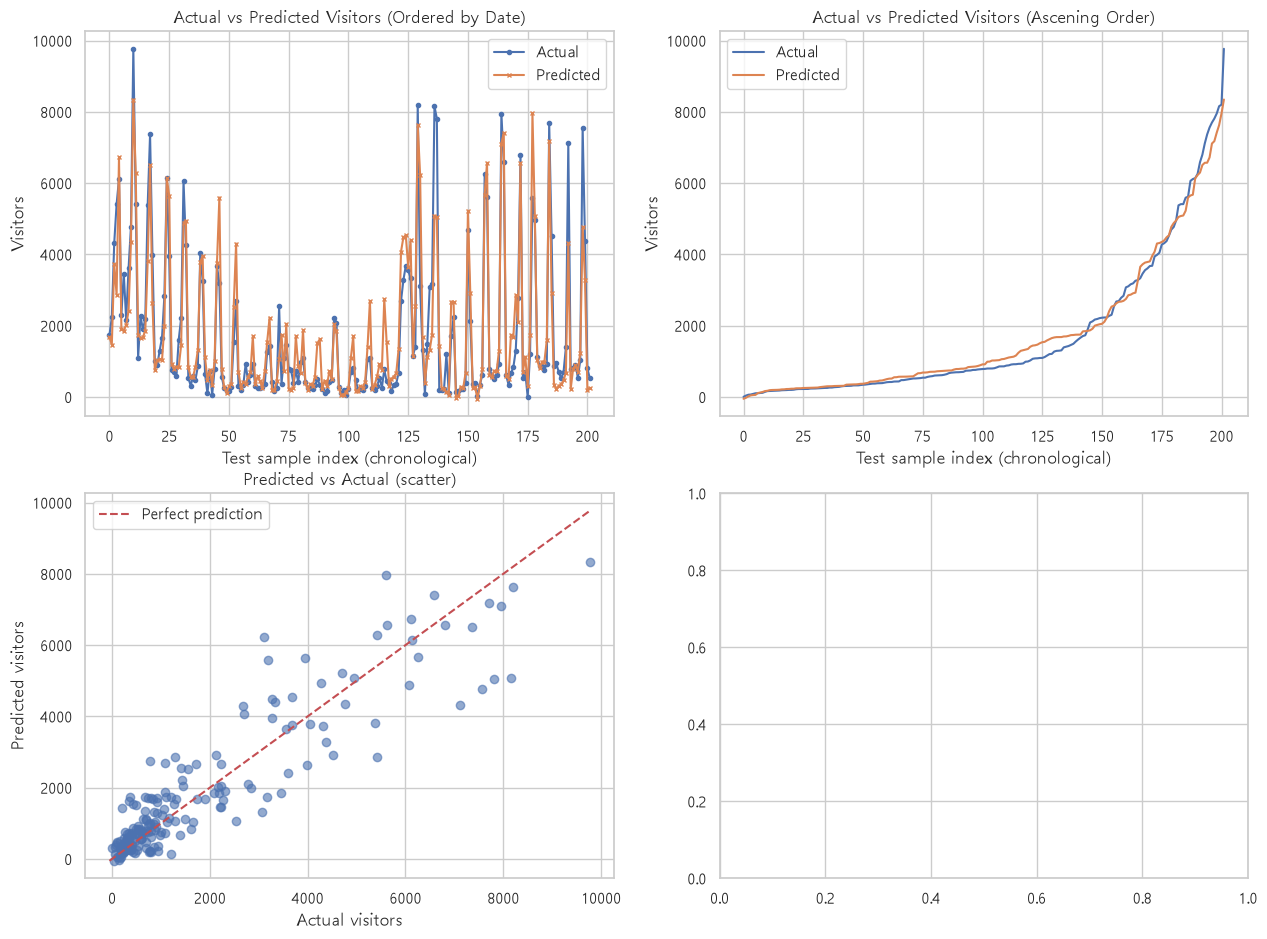

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

#날짜 순으로 Actual, Prediction 비교
axes[0, 0].plot(y_test.values, label="Actual", marker="o", markersize=3)
axes[0, 0].plot(y_pred, label="Predicted", marker="x", markersize=3)
axes[0, 0].set_title("Actual vs Predicted Visitors (Ordered by Date)")
axes[0, 0].set_xlabel("Test sample index (chronological)")
axes[0, 0].set_ylabel("Visitors")
axes[0, 0].legend()

#이용자 수 순으로 Actual, Prediction 비교(선형)
axes[0, 1].plot(np.sort(y_test.values), label="Actual")
axes[0, 1].plot(np.sort(y_pred), label="Predicted")
axes[0, 1].set_title("Actual vs Predicted Visitors (Ascening Order)")
axes[0, 1].set_xlabel("Test sample index (chronological)")
axes[0, 1].set_ylabel("Visitors")
axes[0, 1].legend()

#Actual과 Prediction의 오차 정도 확인
axes[1, 0].scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1, 0].plot(lims, lims, "r--", label="Perfect prediction")
axes[1, 0].set_title("Predicted vs Actual (scatter)")
axes[1, 0].set_xlabel("Actual visitors")
axes[1, 0].set_ylabel("Predicted visitors")
axes[1, 0].legend()

In [38]:
# Random 데이터를 활용하여 Test(Classification과 비교 예정)
example = pd.read_csv("random_data.csv")

predictions = model.predict(example)

for i in range(len(example)):
    example_pred = predictions[i]
    print(f"\nday {i}: {max(0, example_pred-mae):,.0f} ~ {example_pred+mae:,.0f} visitors")


day 0: 6,567 ~ 7,685 visitors

day 1: 2,101 ~ 3,219 visitors

day 2: 5,336 ~ 6,454 visitors

day 3: 1,652 ~ 2,770 visitors

day 4: 2,366 ~ 3,484 visitors

day 5: 4,285 ~ 5,403 visitors

day 6: 2,077 ~ 3,195 visitors

day 7: 1,401 ~ 2,519 visitors

day 8: 3,161 ~ 4,279 visitors

day 9: 1,360 ~ 2,477 visitors

day 10: 1,444 ~ 2,562 visitors

day 11: 1,371 ~ 2,489 visitors

day 12: 0 ~ 1,006 visitors

day 13: 153 ~ 1,271 visitors

day 14: 8,102 ~ 9,220 visitors

day 15: 4,839 ~ 5,957 visitors

day 16: 0 ~ 758 visitors

day 17: 6,298 ~ 7,416 visitors

day 18: 6 ~ 1,124 visitors

day 19: 447 ~ 1,565 visitors

day 20: 901 ~ 2,019 visitors

day 21: 691 ~ 1,808 visitors

day 22: 2,116 ~ 3,234 visitors

day 23: 777 ~ 1,895 visitors

day 24: 4,253 ~ 5,371 visitors

day 25: 3,470 ~ 4,588 visitors

day 26: 4,281 ~ 5,399 visitors

day 27: 708 ~ 1,825 visitors

day 28: 2,171 ~ 3,289 visitors

day 29: 440 ~ 1,558 visitors

day 30: 5,326 ~ 6,444 visitors

day 31: 234 ~ 1,352 visitors

day 32: 5,783 ~